In [1]:
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
import google.generativeai as genai
from langchain.schema import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
import re

In [2]:
# Gemini Flash for faster planning
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    google_api_key="GOOGLE_API_KEY",   # here replace GOOGLE_API_KEY with original *api*
    temperature=0.3
)


In [3]:
# ==== 1. User Travel Input ====
def get_travel_input(state):
    state["travel_input"] = {
        "destination": "Hyderabad",
        "area": "HITEC city",
        "duration_days": 3,
        "budget": 7000,  # INR per person
        "travel_type": "budget",
        "interests": ["sightseeing", "local food"]
    }
    return state

In [4]:
# ==== 2. Analyze Preferences ====
def analyze_travel_profile(state):
    t = state["travel_input"]
    prompt = f"""
    You are a smart travel agent. Analyze the following user preferences:
    - Destination: {t['destination']} ({t['area']})
    - Duration: {t['duration_days']} days
    - Budget: ₹{t['budget']} total
    - Travel type: {t['travel_type']}
    - Interests: {", ".join(t['interests'])}

    Give a short summary and note any constraints or considerations.
    """
    state["travel_summary"] = llm.predict(prompt)
    return state

In [5]:
# ==== 3. Suggest Hotels ====
def suggest_hotels(state):
    t = state["travel_input"]
    prompt = f"""
    Recommend 2 budget-friendly hotels in or near {t['area']}, {t['destination']} 
    for {t['duration_days']} days stay under ₹{t['budget']} total.

    For each hotel, include:
    - Name
    - Approx. price per night
    - Total cost
    - Reason it's a good choice
    """
    state["hotel_options"] = llm.predict(prompt)
    return state

In [6]:
# ==== 4. Places to Visit ====
def suggest_places(state):
    t = state["travel_input"]
    prompt = f"""
    Suggest 5 must-visit places in or near {t['destination']} focusing on:
    - Interests: {", ".join(t['interests'])}
    - Budget constraints (travel type: {t['travel_type']})
    - Located within 10-15 km of {t['area']}

    Include place name and reason to visit.
    """
    state["places_to_visit"] = llm.predict(prompt)
    return state

In [7]:
# ==== 5. Cost Estimation ====
def cost_estimator(state):
    prompt = f"""
    Estimate the total travel cost for this 3-day trip to Hyderabad with the following:
    - Hotel: use details below
{state['hotel_options']}

    - Sightseeing: based on these places
{state['places_to_visit']}

    Break down cost for:
    - Hotel stay
    - Transport/local travel
    - Food
    - Entry tickets (if any)
    - Misc

    Give total cost and whether it's within ₹{state['travel_input']['budget']}.
    """
    state["cost_estimate"] = llm.predict(prompt)
    return state

In [8]:
# ==== 6. Final Travel Plan ====
def travel_summary(state):
    summary = f"""
    Travel Summary:
{state['travel_summary']}

    Hotel Options:
{state['hotel_options']}

    Places to Visit:
{state['places_to_visit']}

    Cost Estimate:
{state['cost_estimate']}
"""
    state["summary"] = summary
    return state

In [9]:
# ==== BUILD GRAPH ====
graph = StateGraph(dict)
graph.add_node("input", get_travel_input)
graph.add_node("analyze", analyze_travel_profile)
graph.add_node("hotels", suggest_hotels)
graph.add_node("places", suggest_places)
graph.add_node("cost", cost_estimator)
graph.add_node("summary", travel_summary)

graph.set_entry_point("input")
graph.add_edge("input", "analyze")
graph.add_edge("analyze", "hotels")
graph.add_edge("hotels", "places")
graph.add_edge("places", "cost")
graph.add_edge("cost", "summary")
graph.set_finish_point("summary")


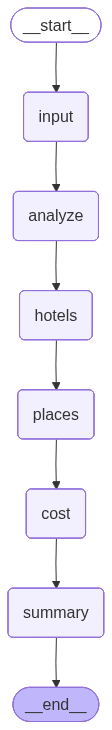

In [10]:
graph.compile()

In [11]:
result = graph.compile().invoke({})
print(result["summary"])


C:\Users\kumma\AppData\Local\Temp\ipykernel_10444\4203023958.py:14: LangChainDeprecationWarning: The method `BaseChatModel.predict` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  state["travel_summary"] = llm.predict(prompt)



    Travel Summary:
Okay, here's a summary and analysis of the user's travel preferences:

**Summary:**

The user wants a budget-friendly, 3-day trip to Hyderabad, specifically focusing on the HITEC City area. They are interested in sightseeing and experiencing local cuisine.

**Constraints and Considerations:**

*   **Budget:** ₹7000 for 3 days is a tight budget, especially considering accommodation, transportation, food, and entry fees. Careful planning and prioritization are crucial.
*   **Location Focus:** HITEC City is a modern IT hub. While it has some attractions and good food options, it's not the historical heart of Hyderabad. Balancing HITEC City with visits to more traditional areas will be important for a well-rounded sightseeing experience.
*   **Transportation:** Transportation costs within Hyderabad can add up. Public transport (buses, metro) and ride-sharing services (Ola/Uber) will need to be considered carefully to stay within budget.
*   **Accommodation:** Budget-fr

In [12]:


# # ==== BUILD GRAPH ====
# graph = StateGraph(dict)
# graph.add_node("input", get_travel_input)
# graph.add_node("analyze", analyze_travel_profile)
# graph.add_node("hotels", suggest_hotels)
# graph.add_node("places", suggest_places)
# graph.add_node("cost", cost_estimator)
# graph.add_node("summary", travel_summary)

# graph.set_entry_point("input")
# graph.add_edge("input", "analyze")
# graph.add_edge("analyze", "hotels")
# graph.add_edge("hotels", "places")
# graph.add_edge("places", "cost")
# graph.add_edge("cost", "summary")
# graph.set_finish_point("summary")

# # ==== RUN ====
# result = graph.compile().invoke({})
# print(result["summary"])
